# Downstream Beam Prediction 

## 1. Path setup

In [ ]:
import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "src").is_dir() and (parent / "data").is_dir():
            return parent
    return start.parent


REPO_ROOT = _find_repo_root(Path.cwd())
DATA_DIR    = REPO_ROOT / "data" / "Scenario5"
RESULTS_DIR = REPO_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
CSV_DIR     = RESULTS_DIR / "csv"
CSV_DIR.mkdir(parents=True, exist_ok=True)

for _p in (REPO_ROOT, REPO_ROOT / "src"):
    _sp = str(_p.resolve())
    if _p.exists() and _sp not in sys.path:
        sys.path.insert(0, _sp)

print("REPO_ROOT:", REPO_ROOT)
print("DATA_DIR :", DATA_DIR)

REPO_ROOT: c:\Users\Kenneth Chan\Documents\School\Research Project\Repo\ImputationFor6GDatasets
DATA_DIR : c:\Users\Kenneth Chan\Documents\School\Research Project\Repo\ImputationFor6GDatasets\data\Scenario5


## 2. Load clean data and the aligned `seq_index` groups

The grouping array MUST be in the same row order as `clean_data`. We read `seq_index`
from the same CSV and assert lengths match. **If the assert fails**, `load_scenario5_clean`
drops or reorders rows — replicate that filtering on `seq_groups` before continuing.

In [ ]:
import numpy as np
import pandas as pd

from common.scenario5.scenario5_data import load_scenario5_clean

clean_data = load_scenario5_clean(DATA_DIR)

_df_raw = pd.read_csv(DATA_DIR / "scenario5.csv")
_df_raw = _df_raw.loc[:, ~_df_raw.columns.str.contains("^Unnamed")]
seq_groups = _df_raw["seq_index"].to_numpy()

assert len(seq_groups) == len(clean_data), (
    f"MISALIGNED: seq_groups has {len(seq_groups)} rows but clean_data has "
    f"{len(clean_data)}. load_scenario5_clean likely filters/reorders rows; "
    f"replicate that operation on seq_groups before continuing."
)

n_sequences = len(np.unique(seq_groups))
_counts = pd.Series(seq_groups).value_counts()
print(f"Rows: {len(clean_data)}  |  distinct sequences: {n_sequences}")
print(f"Rows per sequence (min/median/max): "
      f"{_counts.min()} / {int(_counts.median())} / {_counts.max()}")

Parsing location files...
Parsing mmWave power files...
Argmax matches unit1_beam_index: 100.00%
Clean data shape: (2300, 70)
Missing values after parsing: 0
Rows: 2300  |  distinct sequences: 29
Rows per sequence (min/median/max): 49 / 76 / 127


# 3. Drop unnecessary columns

In [ ]:
from sklearn.preprocessing import StandardScaler

BEAM_COLS = [f"beam_{i:02d}" for i in range(64)]
GPS_COLS = [
    "unit2_lat", "unit2_lon", "unit2_direction",
    "unit2_num_sat", "unit2_PDOP", "unit2_HDOP",
]
RETAINED_COLS = BEAM_COLS + GPS_COLS

clean_df = (clean_data[RETAINED_COLS].copy()
            if isinstance(clean_data, pd.DataFrame)
            else pd.DataFrame(clean_data, columns=RETAINED_COLS))

scaler = StandardScaler()
data_scaled = scaler.fit_transform(clean_df.to_numpy(dtype=float))

beam_idx = np.array([RETAINED_COLS.index(c) for c in BEAM_COLS])
gps_idx  = np.array([RETAINED_COLS.index(c) for c in GPS_COLS])

assert set(gps_idx.tolist()).isdisjoint(set(beam_idx.tolist())), (
    "LEAKAGE: gps_idx and beam_idx overlap — predictor features include label-source columns."
)

print("data_scaled:", data_scaled.shape)
print("beam_idx:", beam_idx.min(), "..", beam_idx.max(), "| gps_idx:", gps_idx.tolist())
print("Leakage guard passed: GPS features disjoint from beam label-source.")


data_scaled: (2300, 70)
beam_idx: 0 .. 63 | gps_idx: [64, 65, 66, 67, 68, 69]
Leakage guard passed: GPS features disjoint from beam label-source.


## 4. Predictor + Top-K metric 

In [ ]:
import torch
import torch.nn as nn


def predict_topk_mlp(gps_train, labels_train, gps_test,
                     n_classes=64, hidden=256, n_layers=3,
                     epochs=60, lr=1e-2, batch_size=32,
                     val_frac=0.25, seed=0, device=None):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    torch.manual_seed(seed)
    np.random.seed(seed)

    y = labels_train.astype(int) - 1  # 1..64 -> 0..63

    n = len(gps_train)
    perm = np.random.default_rng(seed).permutation(n)
    n_val = max(1, int(round(val_frac * n)))
    val_i, tr_i = perm[:n_val], perm[n_val:]

    Xtr = torch.tensor(gps_train[tr_i], dtype=torch.float32, device=device)
    ytr = torch.tensor(y[tr_i],         dtype=torch.long,    device=device)
    Xva = torch.tensor(gps_train[val_i], dtype=torch.float32, device=device)
    yva = torch.tensor(y[val_i],         dtype=torch.long,    device=device)
    Xte = torch.tensor(gps_test,         dtype=torch.float32, device=device)

    layers, in_dim = [], gps_train.shape[1]
    for _ in range(n_layers):
        layers += [nn.Linear(in_dim, hidden), nn.ReLU()]
        in_dim = hidden
    layers += [nn.Linear(in_dim, n_classes)]
    model = nn.Sequential(*layers).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[20, 40], gamma=0.2)
    loss_fn = nn.CrossEntropyLoss()

    best_state, best_val_acc = None, -1.0
    idx = np.arange(len(tr_i))
    for epoch in range(epochs):
        model.train()
        np.random.shuffle(idx)
        for s in range(0, len(idx), batch_size):
            b = idx[s:s + batch_size]
            opt.zero_grad()
            loss = loss_fn(model(Xtr[b]), ytr[b])
            loss.backward()
            opt.step()
        sched.step()

        model.eval()
        with torch.no_grad():
            val_acc = (model(Xva).argmax(1) == yva).float().mean().item()
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        logits = model(Xte).cpu().numpy()

    ranked_idx = np.argsort(-logits, axis=1)
    return ranked_idx + 1


def topk_accuracy(ranked_labels, true_labels, top_k=(1, 2, 3, 4, 5)):
    out = {}
    for k in top_k:
        in_topk = np.any(ranked_labels[:, :k] == true_labels[:, None], axis=1)
        out[f"top{k}_acc"] = float(in_topk.mean())
    return out

## 5. Grouped downstream evaluation

Takes a `train_idx`/`test_idx` pair already produced by a grouped splitter, so the same
function serves both a single `GroupShuffleSplit` and each `GroupKFold` fold.
`imputer=None` is the **clean baseline** (train labels from un-amputed beams).

In [ ]:
def _fill_residual_nans(imputed, reference_masked):
    """Belt-and-braces: if an imputer leaves NaNs, fill with column means."""
    if np.isnan(imputed).any():
        col_means = np.nanmean(reference_masked, axis=0)
        col_means = np.where(np.isnan(col_means), 0.0, col_means)
        nan_pos = np.isnan(imputed)
        imputed[nan_pos] = np.take(col_means, np.where(nan_pos)[1])
    return imputed


def downstream_eval(data_scaled, beam_idx, gps_idx, mask, imputer,
                            seed, train_idx, test_idx,
                            precomputed_imputed=None):
    if imputer is None:
        train_beams = data_scaled[train_idx][:, beam_idx]
    elif precomputed_imputed is not None:
        train_beams = precomputed_imputed[train_idx][:, beam_idx]

    else:
        data_train_masked = data_scaled[train_idx].copy()
        data_train_masked[mask[train_idx]] = np.nan
        data_train_imputed = imputer.fit_transform(data_train_masked, seed=seed)
        data_train_imputed = _fill_residual_nans(data_train_imputed, data_train_masked)
        train_beams = data_train_imputed[:, beam_idx]

    test_beams_clean = data_scaled[test_idx][:, beam_idx]
    labels_train = np.argmax(train_beams,      axis=1) + 1
    labels_test  = np.argmax(test_beams_clean, axis=1) + 1

    gps_train = data_scaled[train_idx][:, gps_idx]
    gps_test  = data_scaled[test_idx][:,  gps_idx]

    ranked = predict_topk_mlp(gps_train, labels_train, gps_test, seed=seed)
    return topk_accuracy(ranked, labels_test, top_k=(1, 2, 3, 4, 5))


## 6. Splitter that adapts to sequence count

Few sequences → `GroupKFold` (each sequence is test exactly once; average folds).
Many → a single `GroupShuffleSplit`. Threshold editable.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit, GroupKFold

FEW_SEQ_THRESHOLD = 40   


def grouped_splits(groups, seed, n_folds=3, test_size=0.2):
    n_rows = len(groups)
    n_seq = len(np.unique(groups))
    all_idx = np.arange(n_rows)

    if n_seq <= FEW_SEQ_THRESHOLD:
        k = min(n_folds, n_seq)
        gkf = GroupKFold(n_splits=k)
        for tr, te in gkf.split(all_idx, groups=groups):
            assert set(groups[tr]).isdisjoint(set(groups[te]))
            yield tr, te
    else:
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        tr, te = next(gss.split(all_idx, groups=groups))
        assert set(groups[tr]).isdisjoint(set(groups[te]))
        yield tr, te


print(f"Splitter: {'GroupKFold' if n_sequences <= FEW_SEQ_THRESHOLD else 'GroupShuffleSplit'} "
      f"({n_sequences} sequences).")


Splitter: GroupKFold (29 sequences).


## 7. Build masks for each (mechanism, proportion)

The mask is dataset-level; the grouped split only changes which *rows* are train.
The MCAR builder is inline; for MAR/MNAR, wire in the project's helper (restricted to
`beam_idx`) where indicated.

In [ ]:
from common.amputation import build_mask

MECHANISMS  = ["MCAR", "MAR", "MNAR"]
PROPORTIONS = [0.10, 0.30, 0.50]
SEED = 0

mar_driver_idx = [RETAINED_COLS.index("unit2_HDOP")]   

_rng = np.random.default_rng(SEED)
_m = build_mask("MCAR", data_scaled, 0.10, beam_idx, _rng,
                driver_col_idx=mar_driver_idx, mar_score_mode="single")
print("Realised beam missingness:", round(float(_m[:, beam_idx].mean()), 4), "(target 0.10)")
assert not _m[:, gps_idx].any(), "GPS columns were amputed — build_mask not restricted to beams."
print("GPS columns untouched by mask: OK")


Realised beam missingness: 0.1012 (target 0.10)
GPS columns untouched by mask: OK


## 8. Run: clean baseline vs imputers under the grouped split

In [ ]:
import time
from imputers.imputers import (
    MeanImputer, KNNImputerWrapper, SoftImputeWrapper, MICEImputer,
)
from imputers.diffputer_imputer import DiffPuterImputer
from imputers.grape_imputer import GRAPEImputer



FULL_MECH = ["MCAR", "MAR", "MNAR"]
FULL_PROP = [0.10, 0.30, 0.50]

IMPUTERS = [
    ("mean",       MeanImputer(),         FULL_MECH, FULL_PROP, 3, False),  # mean imputation is fast enough to not need caching
    ("knn",        KNNImputerWrapper(),   FULL_MECH, FULL_PROP, 3, False),
    ("softimpute", SoftImputeWrapper(),   FULL_MECH, FULL_PROP, 3, False), 
    ("mice",       MICEImputer(),         FULL_MECH, FULL_PROP, 3, False), 
    ("diffputer",  DiffPuterImputer(),    FULL_MECH, FULL_PROP, 3, False), 
    ("grape",      GRAPEImputer(),        FULL_MECH, FULL_PROP, 3, False),
]

CLEAN_FOLDS = 3 

DOWNSTREAM_PATH = CSV_DIR / "scenario5_downstream_full_results.csv"
CACHE_DIR = RESULTS_DIR / "imputed_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def _cache_path(method, mech, prop):
    return CACHE_DIR / f"{method}__{mech}__p{int(round(prop*100)):02d}.npy"


def get_full_imputation(imputer, method, mech, prop, mask, seed):
    cpath = _cache_path(method, mech, prop)
    if cpath.exists():
        return np.load(cpath)

    data_masked = data_scaled.copy()
    data_masked[mask] = np.nan
    t0 = time.time()
    imputed = imputer.fit_transform(data_masked, seed=seed)
    imputed = _fill_residual_nans(imputed, data_masked)
    np.save(cpath, imputed)
    print(f"  [cache] imputed {method} {mech} p={prop} "
          f"in {time.time()-t0:.1f}s -> {cpath.name}")
    return imputed


# Resume metrics checkpoint.
if DOWNSTREAM_PATH.exists():
    done_df = pd.read_csv(DOWNSTREAM_PATH)
    done_keys = set(zip(done_df["mechanism"], done_df["proportion"], done_df["method"]))
    records = done_df.to_dict("records")
    print(f"Resuming: {len(done_keys)} result cells already in {DOWNSTREAM_PATH.name}.")
else:
    done_keys, records = set(), []


def _append_downstream(row):
    pd.DataFrame([row]).to_csv(
        DOWNSTREAM_PATH, mode="a", header=not DOWNSTREAM_PATH.exists(), index=False
    )


# ---------------------------------------------------------------------------
# CLEAN baseline: compute ONCE (mask-independent), then broadcast to every
# (mechanism, proportion) so the pivot/plots still find a ceiling per panel.
# ---------------------------------------------------------------------------
clean_needed = [(m, p) for m in FULL_MECH for p in FULL_PROP
                if (m, p, "clean") not in done_keys]

if clean_needed:
    t0 = time.time()
    fold_metrics = []
    for tr, te in grouped_splits(seq_groups, seed=SEED, n_folds=CLEAN_FOLDS):
        fold_metrics.append(downstream_eval(
            data_scaled, beam_idx, gps_idx, mask=None, imputer=None,
            seed=SEED, train_idx=tr, test_idx=te, precomputed_imputed=None,
        ))
    clean_stats = {"n_folds": len(fold_metrics), "cached": False,
                   "secs": round(time.time() - t0, 1)}
    for k in fold_metrics[0]:
        vals = [fm[k] for fm in fold_metrics]
        clean_stats[k] = float(np.mean(vals))
        clean_stats[f"{k}_std"] = float(np.std(vals))

    # Broadcast the single result across all (mech, prop) panels.
    for mech, prop in clean_needed:
        row = {"mechanism": mech, "proportion": prop, "method": "clean", **clean_stats}
        records.append(row)
        done_keys.add((mech, prop, "clean"))
        _append_downstream(row)
    print(f"clean (computed once, {clean_stats['n_folds']} folds, "
          f"{clean_stats['secs']}s) broadcast to {len(clean_needed)} cells: "
          f"top1={clean_stats['top1_acc']:.3f} top5={clean_stats['top5_acc']:.3f}")


# ---------------------------------------------------------------------------
# All other methods: mask matters, run the grid as before.
# ---------------------------------------------------------------------------
for label, imp, mechs, props, n_folds, per_fold_refit in IMPUTERS:
    for mech in mechs:
        for prop in props:
            key = (mech, prop, label)
            if key in done_keys:
                continue

            rng = np.random.default_rng(SEED)
            mask = build_mask(mech, data_scaled, prop, beam_idx, rng,
                              driver_col_idx=mar_driver_idx, mar_score_mode="single")

            precomputed = None
            if imp is not None and not per_fold_refit:
                precomputed = get_full_imputation(imp, label, mech, prop, mask, SEED)

            t0 = time.time()
            fold_metrics = []
            for tr, te in grouped_splits(seq_groups, seed=SEED, n_folds=n_folds):
                fold_metrics.append(downstream_eval(
                    data_scaled, beam_idx, gps_idx, mask, imp,
                    seed=SEED, train_idx=tr, test_idx=te,
                    precomputed_imputed=precomputed,
                ))

            row = {"mechanism": mech, "proportion": prop, "method": label,
                   "n_folds": len(fold_metrics),
                   "cached": (not per_fold_refit) and imp is not None,
                   "secs": round(time.time() - t0, 1)}
            for k in fold_metrics[0]:
                vals = [fm[k] for fm in fold_metrics]
                row[k] = float(np.mean(vals))
                row[f"{k}_std"] = float(np.std(vals))

            records.append(row)
            done_keys.add(key)
            _append_downstream(row)
            print(f"{mech} p={prop} {label:10s} "
                  f"top1={row['top1_acc']:.3f}±{row['top1_acc_std']:.3f} "
                  f"top5={row['top5_acc']:.3f}  "
                  f"({row['n_folds']}f, {'cached' if row['cached'] else 'refit'}, "
                  f"{row['secs']}s)")

results = pd.DataFrame(records)
results

Resuming: 10 result cells already in scenario5_downstream_results.csv.
MCAR p=0.3 mean       top1=0.226±0.045 top5=0.735  (5f, refit, 35.8s)
MCAR p=0.5 mean       top1=0.203±0.038 top5=0.712  (5f, refit, 34.6s)
MAR p=0.1 mean       top1=0.227±0.030 top5=0.736  (5f, refit, 39.7s)
MAR p=0.3 mean       top1=0.229±0.035 top5=0.725  (5f, refit, 38.5s)
MAR p=0.5 mean       top1=0.187±0.028 top5=0.641  (5f, refit, 37.8s)
MNAR p=0.1 mean       top1=0.186±0.027 top5=0.676  (5f, refit, 38.4s)
MNAR p=0.3 mean       top1=0.110±0.029 top5=0.480  (5f, refit, 39.9s)
MNAR p=0.5 mean       top1=0.084±0.028 top5=0.354  (5f, refit, 41.5s)
MCAR p=0.1 knn        top1=0.224±0.043 top5=0.747  (5f, refit, 44.7s)
MCAR p=0.3 knn        top1=0.220±0.036 top5=0.729  (5f, refit, 47.5s)
MCAR p=0.5 knn        top1=0.197±0.033 top5=0.696  (5f, refit, 42.6s)
MAR p=0.1 knn        top1=0.231±0.034 top5=0.746  (5f, refit, 41.0s)


KeyboardInterrupt: 

## 9. Clean vs imputed — the actual comparison


In [ ]:
metric = "top1_acc"
pivot = results.pivot_table(index=["mechanism", "proportion"],
                            columns="method", values=metric)
if "clean" in pivot.columns:
    for col in list(pivot.columns):
        if col != "clean":
            pivot[f"{col}_minus_clean"] = pivot[col] - pivot["clean"]

# Persist final results next to the checkpoint.
results.to_csv(CSV_DIR / "scenario5_downstream_grouped.csv", index=False)
print("Saved:", CSV_DIR / "scenario5_downstream_grouped.csv")
pivot.round(4)


Saved: c:\Users\Kenneth Chan\Documents\School\Research Project\Repo\ImputationFor6GDatasets\results\csv\scenario5_downstream_grouped.csv


method                 clean     knn  knn_minus_clean
mechanism proportion                                 
MAR       0.1         0.2473  0.2284          -0.0190
          0.3         0.2473  0.2049          -0.0424
          0.5         0.2473  0.1694          -0.0779
MCAR      0.1         0.2473  0.2288          -0.0185
          0.3         0.2473  0.2257          -0.0216
          0.5         0.2473  0.1927          -0.0546
MNAR      0.1         0.2473  0.2009          -0.0465
          0.3         0.2473  0.1385          -0.1089
          0.5         0.2473  0.1141          -0.1332

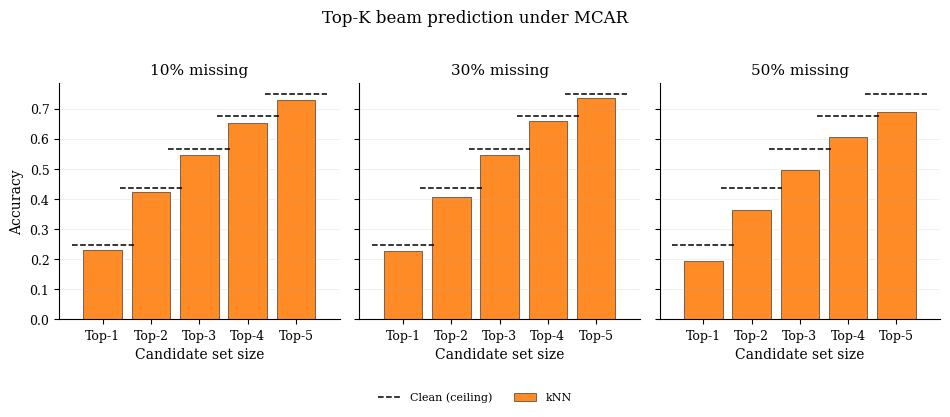

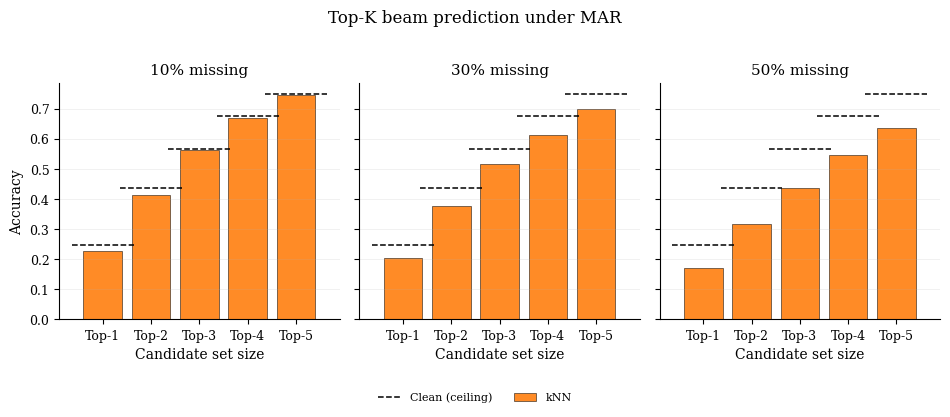

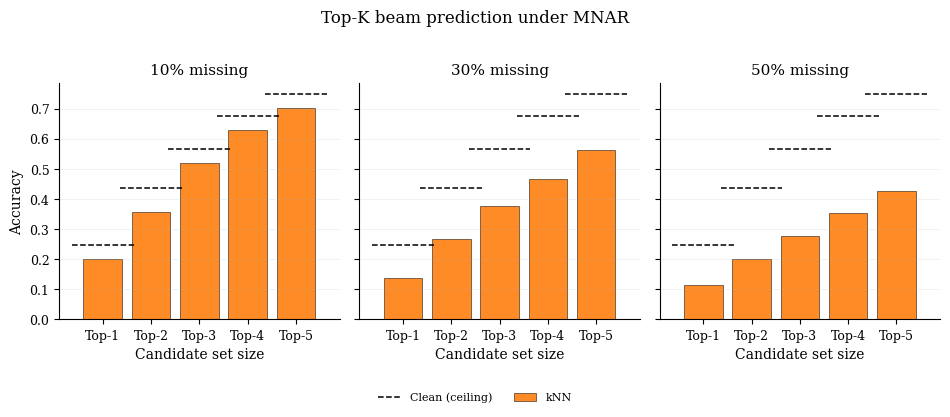

In [ ]:
"""
Scenario-5 downstream Top-K plots.
"""
import matplotlib.pyplot as plt
from common.visualization import METHOD_COLORS

LABEL_TO_DISPLAY = {
    "clean": "Clean", "mean": "Mean", "knn": "kNN", "mice": "MICE",
    "softimpute": "SoftImpute", "hyperimpute": "HyperImpute",
    "grape": "GRAPE", "diffputer": "DiffPuter",
}
IMPUTER_METHODS = ["Mean", "kNN", "MICE", "HyperImpute",
                   "SoftImpute", "GRAPE", "DiffPuter"]


def _as_plot_df(data):
    df = data if isinstance(data, pd.DataFrame) else pd.read_csv(data)
    df = df.copy()
    df["method"] = df["method"].map(lambda m: LABEL_TO_DISPLAY.get(m, m))
    if "scenario" not in df.columns and "mechanism" in df.columns:
        df["scenario"] = df["mechanism"]
    return df


def _present_imputers(sub):
    present = set(sub["method"].unique())
    return [m for m in IMPUTER_METHODS if m in present]


def _draw_topk_panel(ax, sub, methods, show_ylabel, show_legend):
    ks = [1, 2, 3, 4, 5]
    metrics = [f"top{k}_acc" for k in ks]
    bar_width = 0.8 / max(len(methods), 1)
    group_centers = np.arange(len(ks))

    for i, m in enumerate(methods):
        msub = sub[sub["method"] == m]
        means = [msub[met].mean() for met in metrics]
        # Prefer the stored fold std if present, else std across rows.
        stds = []
        for met in metrics:
            std_col = f"{met}_std"
            stds.append(msub[std_col].mean() if std_col in msub else msub[met].std())
        offsets = group_centers - 0.4 + (i + 0.5) * bar_width
        ax.bar(offsets, means, width=bar_width, yerr=stds, label=m,
               color=METHOD_COLORS.get(m), edgecolor="black", linewidth=0.4,
               error_kw=dict(elinewidth=0.7, capsize=1.5, ecolor="black"),
               alpha=0.9)

    clean = sub[sub["method"] == "Clean"]
    if not clean.empty:
        tick_half = bar_width * len(methods) / 2 + bar_width * 0.3
        for j, met in enumerate(metrics):
            ax.hlines(clean[met].mean(),
                      group_centers[j] - tick_half, group_centers[j] + tick_half,
                      color="black", linestyle="--", linewidth=1.1,
                      label="Clean (ceiling)" if j == 0 else None, zorder=10)

    ax.set_xticks(group_centers)
    ax.set_xticklabels([f"Top-{k}" for k in ks])
    ax.set_xlabel("Candidate set size")
    if show_ylabel:
        ax.set_ylabel("Accuracy")
    ax.grid(axis="y", alpha=0.25, linewidth=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if show_legend:
        ax.legend(loc="lower right", ncol=2, fontsize=8, frameon=False)


def plot_topk_comparison_grid(data, scenario="MAR", proportions=None,
                              filename=None, methods=None):
    df = _as_plot_df(data)
    sc = df[df["scenario"] == scenario]
    if sc.empty:
        print(f"[plot] no rows for scenario={scenario}; skipping.")
        return
    proportions = proportions or sorted(sc["proportion"].unique())
    methods = methods or _present_imputers(sc)

    fig, axes = plt.subplots(1, len(proportions),
                             figsize=(3.2 * len(proportions), 3.6),
                             sharey=True)
    if len(proportions) == 1 and not hasattr(axes, "__iter__"):
        axes = [axes]

    for ax_i, (ax, p) in enumerate(zip(axes, proportions)):
        sub = sc[sc["proportion"] == p]
        _draw_topk_panel(ax, sub, methods,
                         show_ylabel=(ax_i == 0), show_legend=False)
        ax.set_title(f"{int(p*100)}% missing")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=min(len(labels), 5),
               bbox_to_anchor=(0.5, -0.10), frameon=False)
    fig.suptitle(f"Top-K beam prediction under {scenario}", y=1.02)
    fig.tight_layout()
    if filename is not None:
        fig.savefig(filename, bbox_inches="tight")
    plt.show()


# ---------------------------------------------------------------------------
# Usage — note heavy methods only populate their trimmed proportions, so some
# panels will show fewer bars; that is expected from the run plan.
# ---------------------------------------------------------------------------
for mech in ["MCAR", "MAR", "MNAR"]:
    plot_topk_comparison_grid(results, scenario=mech,
                              filename=FIGURES_DIR / f"sq3_topk_grid_{mech}.png")
